In [167]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns


In [168]:
df = pd.read_csv('data/BostonHousing.csv')
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [170]:
print(f"dataset shape: {df.shape}")
print(f"dataset missing values: {df.isnull().sum().sum()}")
print(f"dataset duplicate values: {df.duplicated().sum().sum()}")
print(f"dataset columns: {df.columns.tolist()}")

dataset shape: (506, 14)
dataset missing values: 0
dataset duplicate values: 0
dataset columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


### Exploratory Data Analysis

In [171]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [172]:
corr = df.corr()['medv'].sort_values(ascending=False)
corr

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

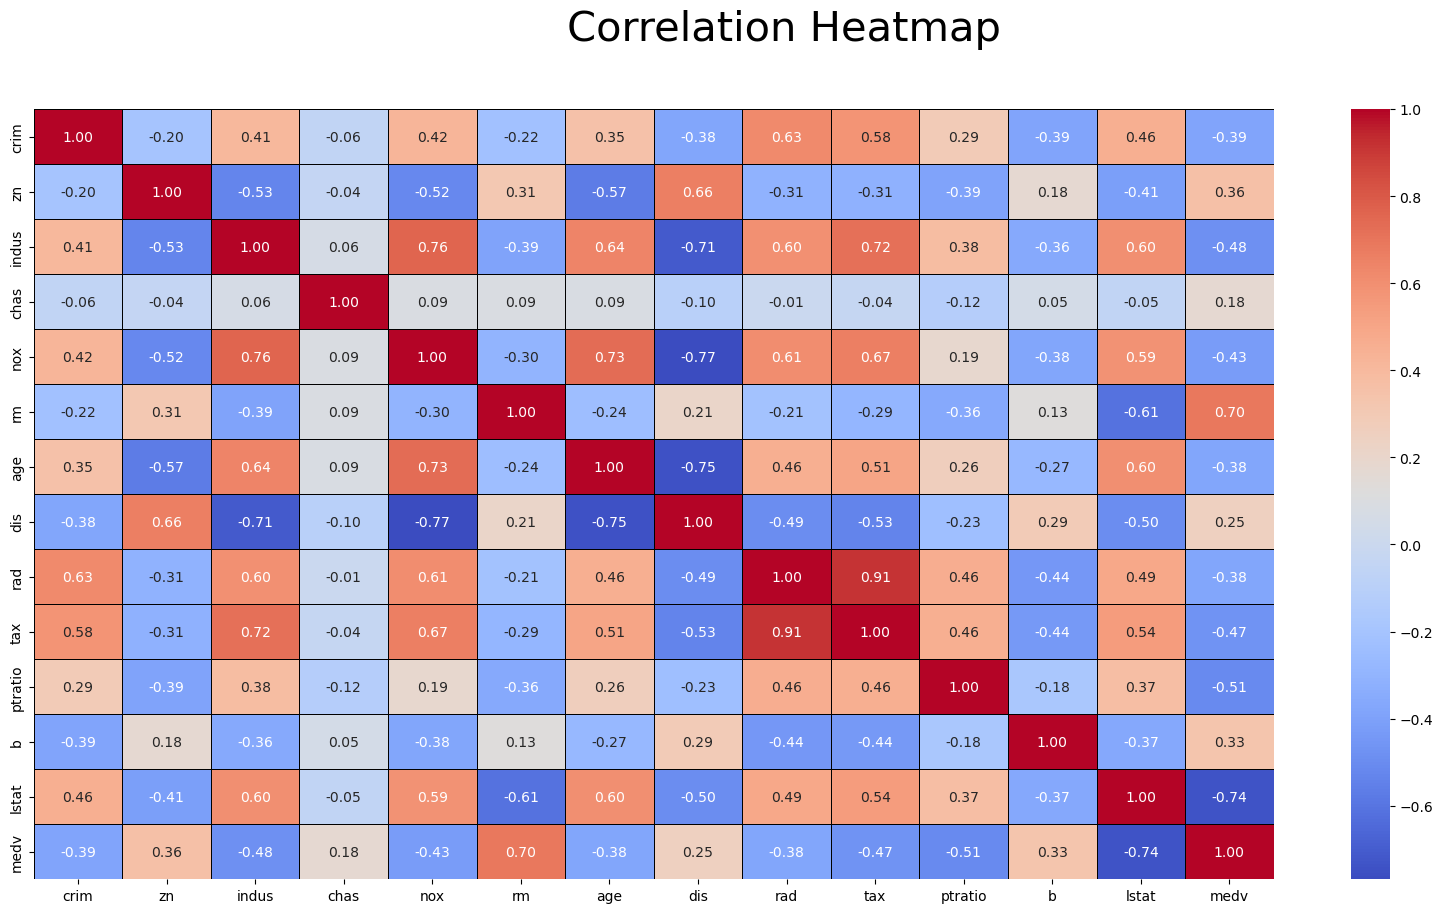

In [173]:
plt.figure(figsize=(20, 10))
plt.suptitle("Correlation Heatmap", fontsize=30)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5, linecolor='black', fmt='.2f')
plt.show()

In [174]:
cols = df.columns.tolist()
cols

['crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'b',
 'lstat',
 'medv']

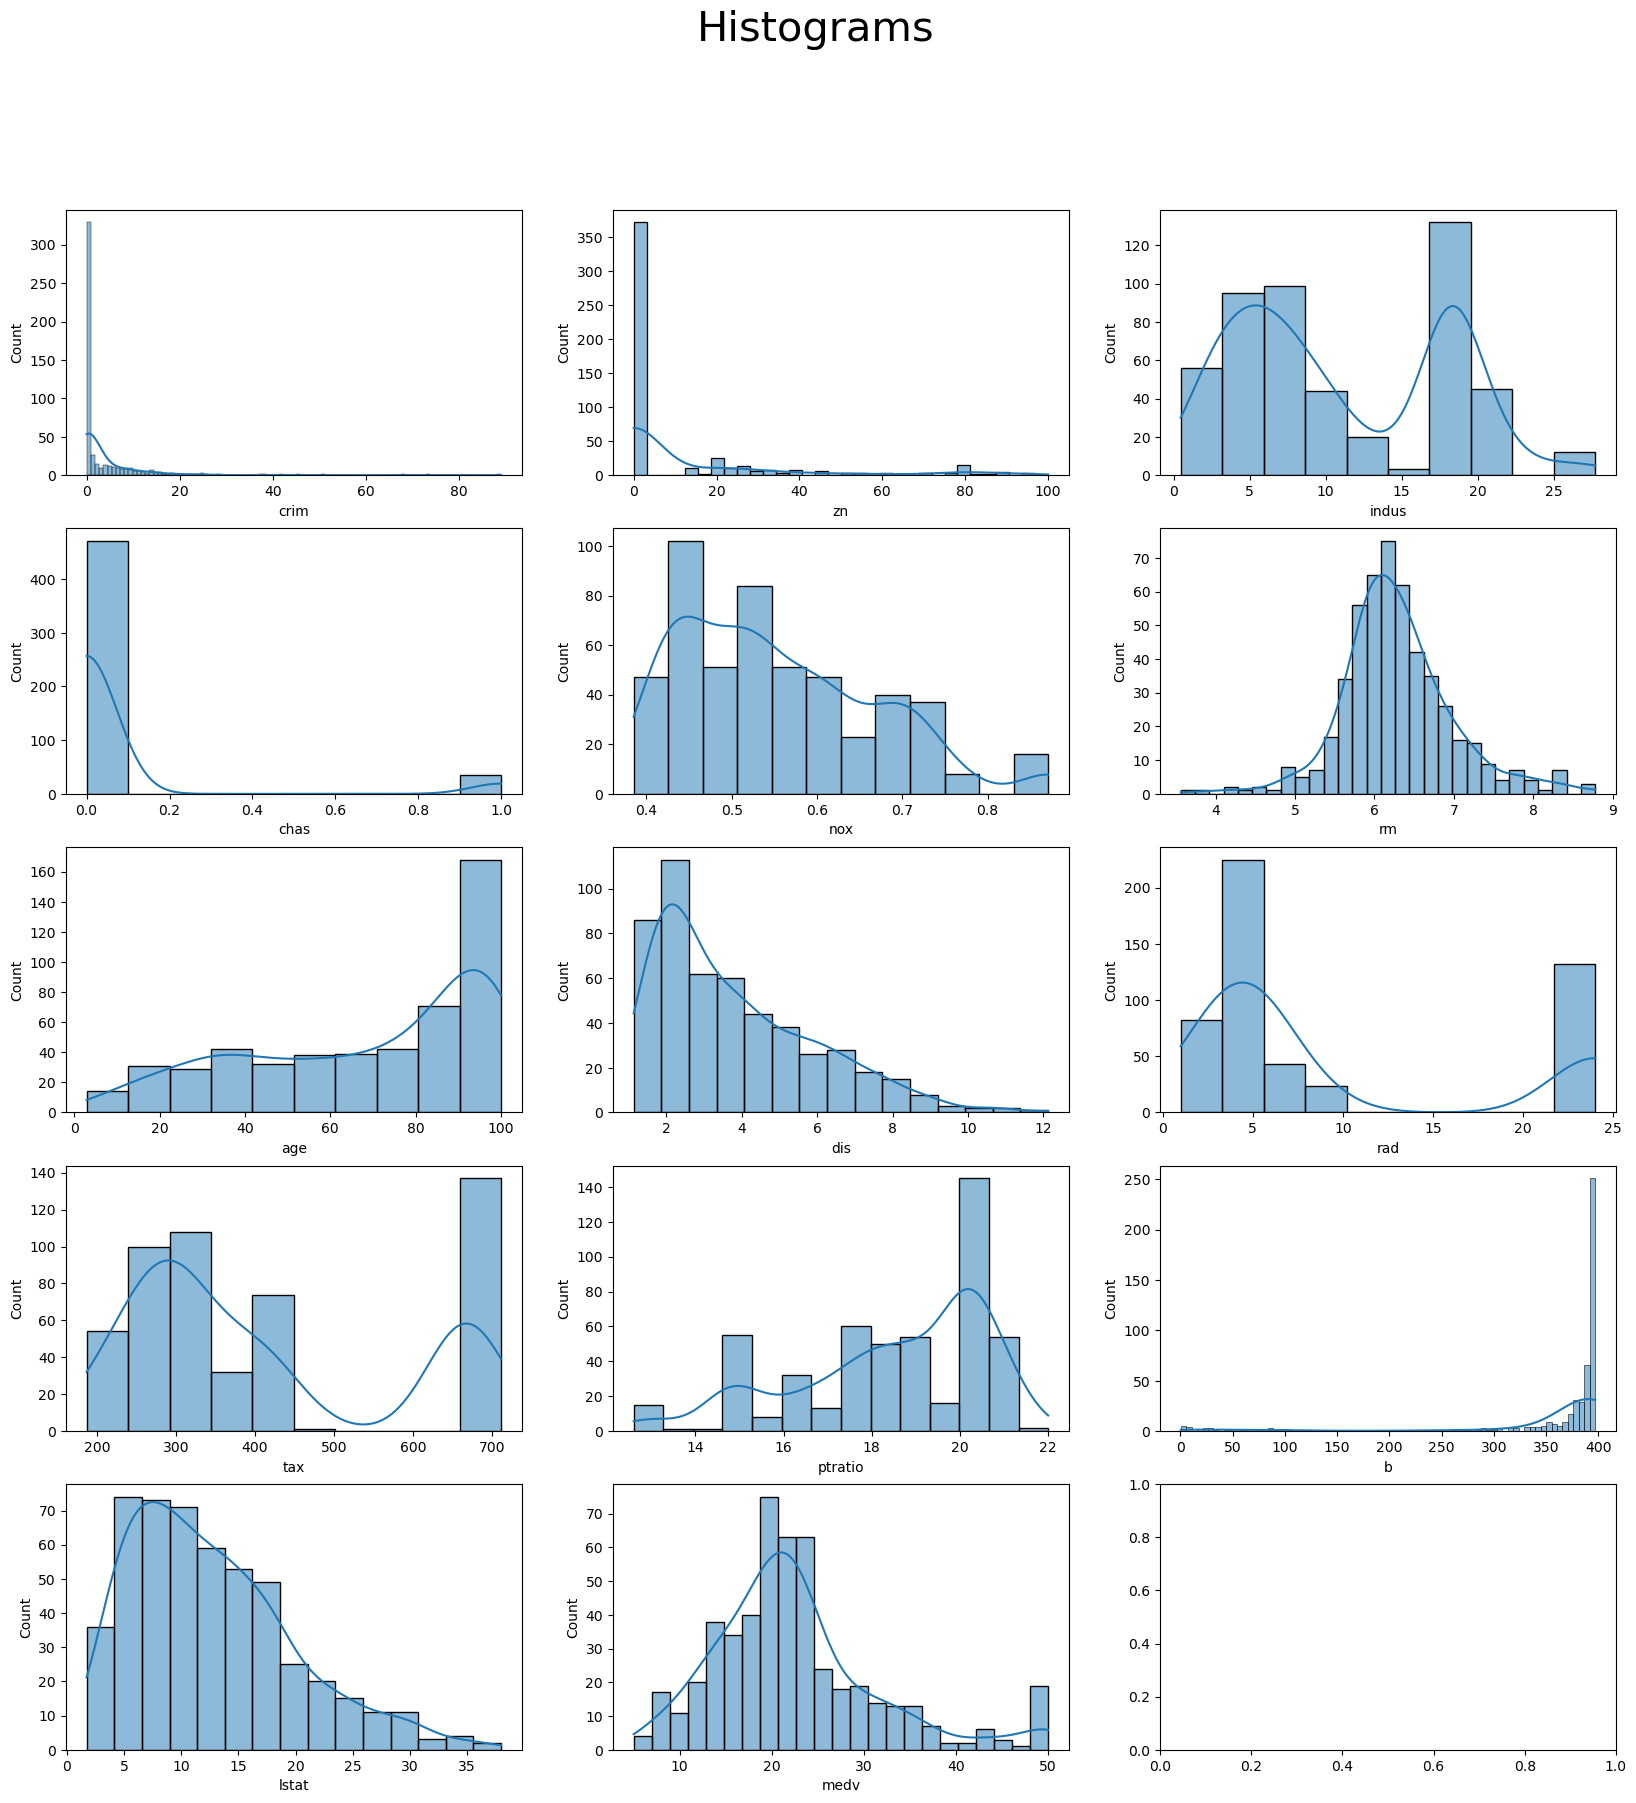

In [175]:
fig, axes = plt.subplots(5, 3, figsize=(20, 20))

fig.suptitle("Histograms", fontsize=30)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    sns.histplot(df[col], ax=ax, kde=True)

plt.show()

<Figure size 2000x2000 with 0 Axes>

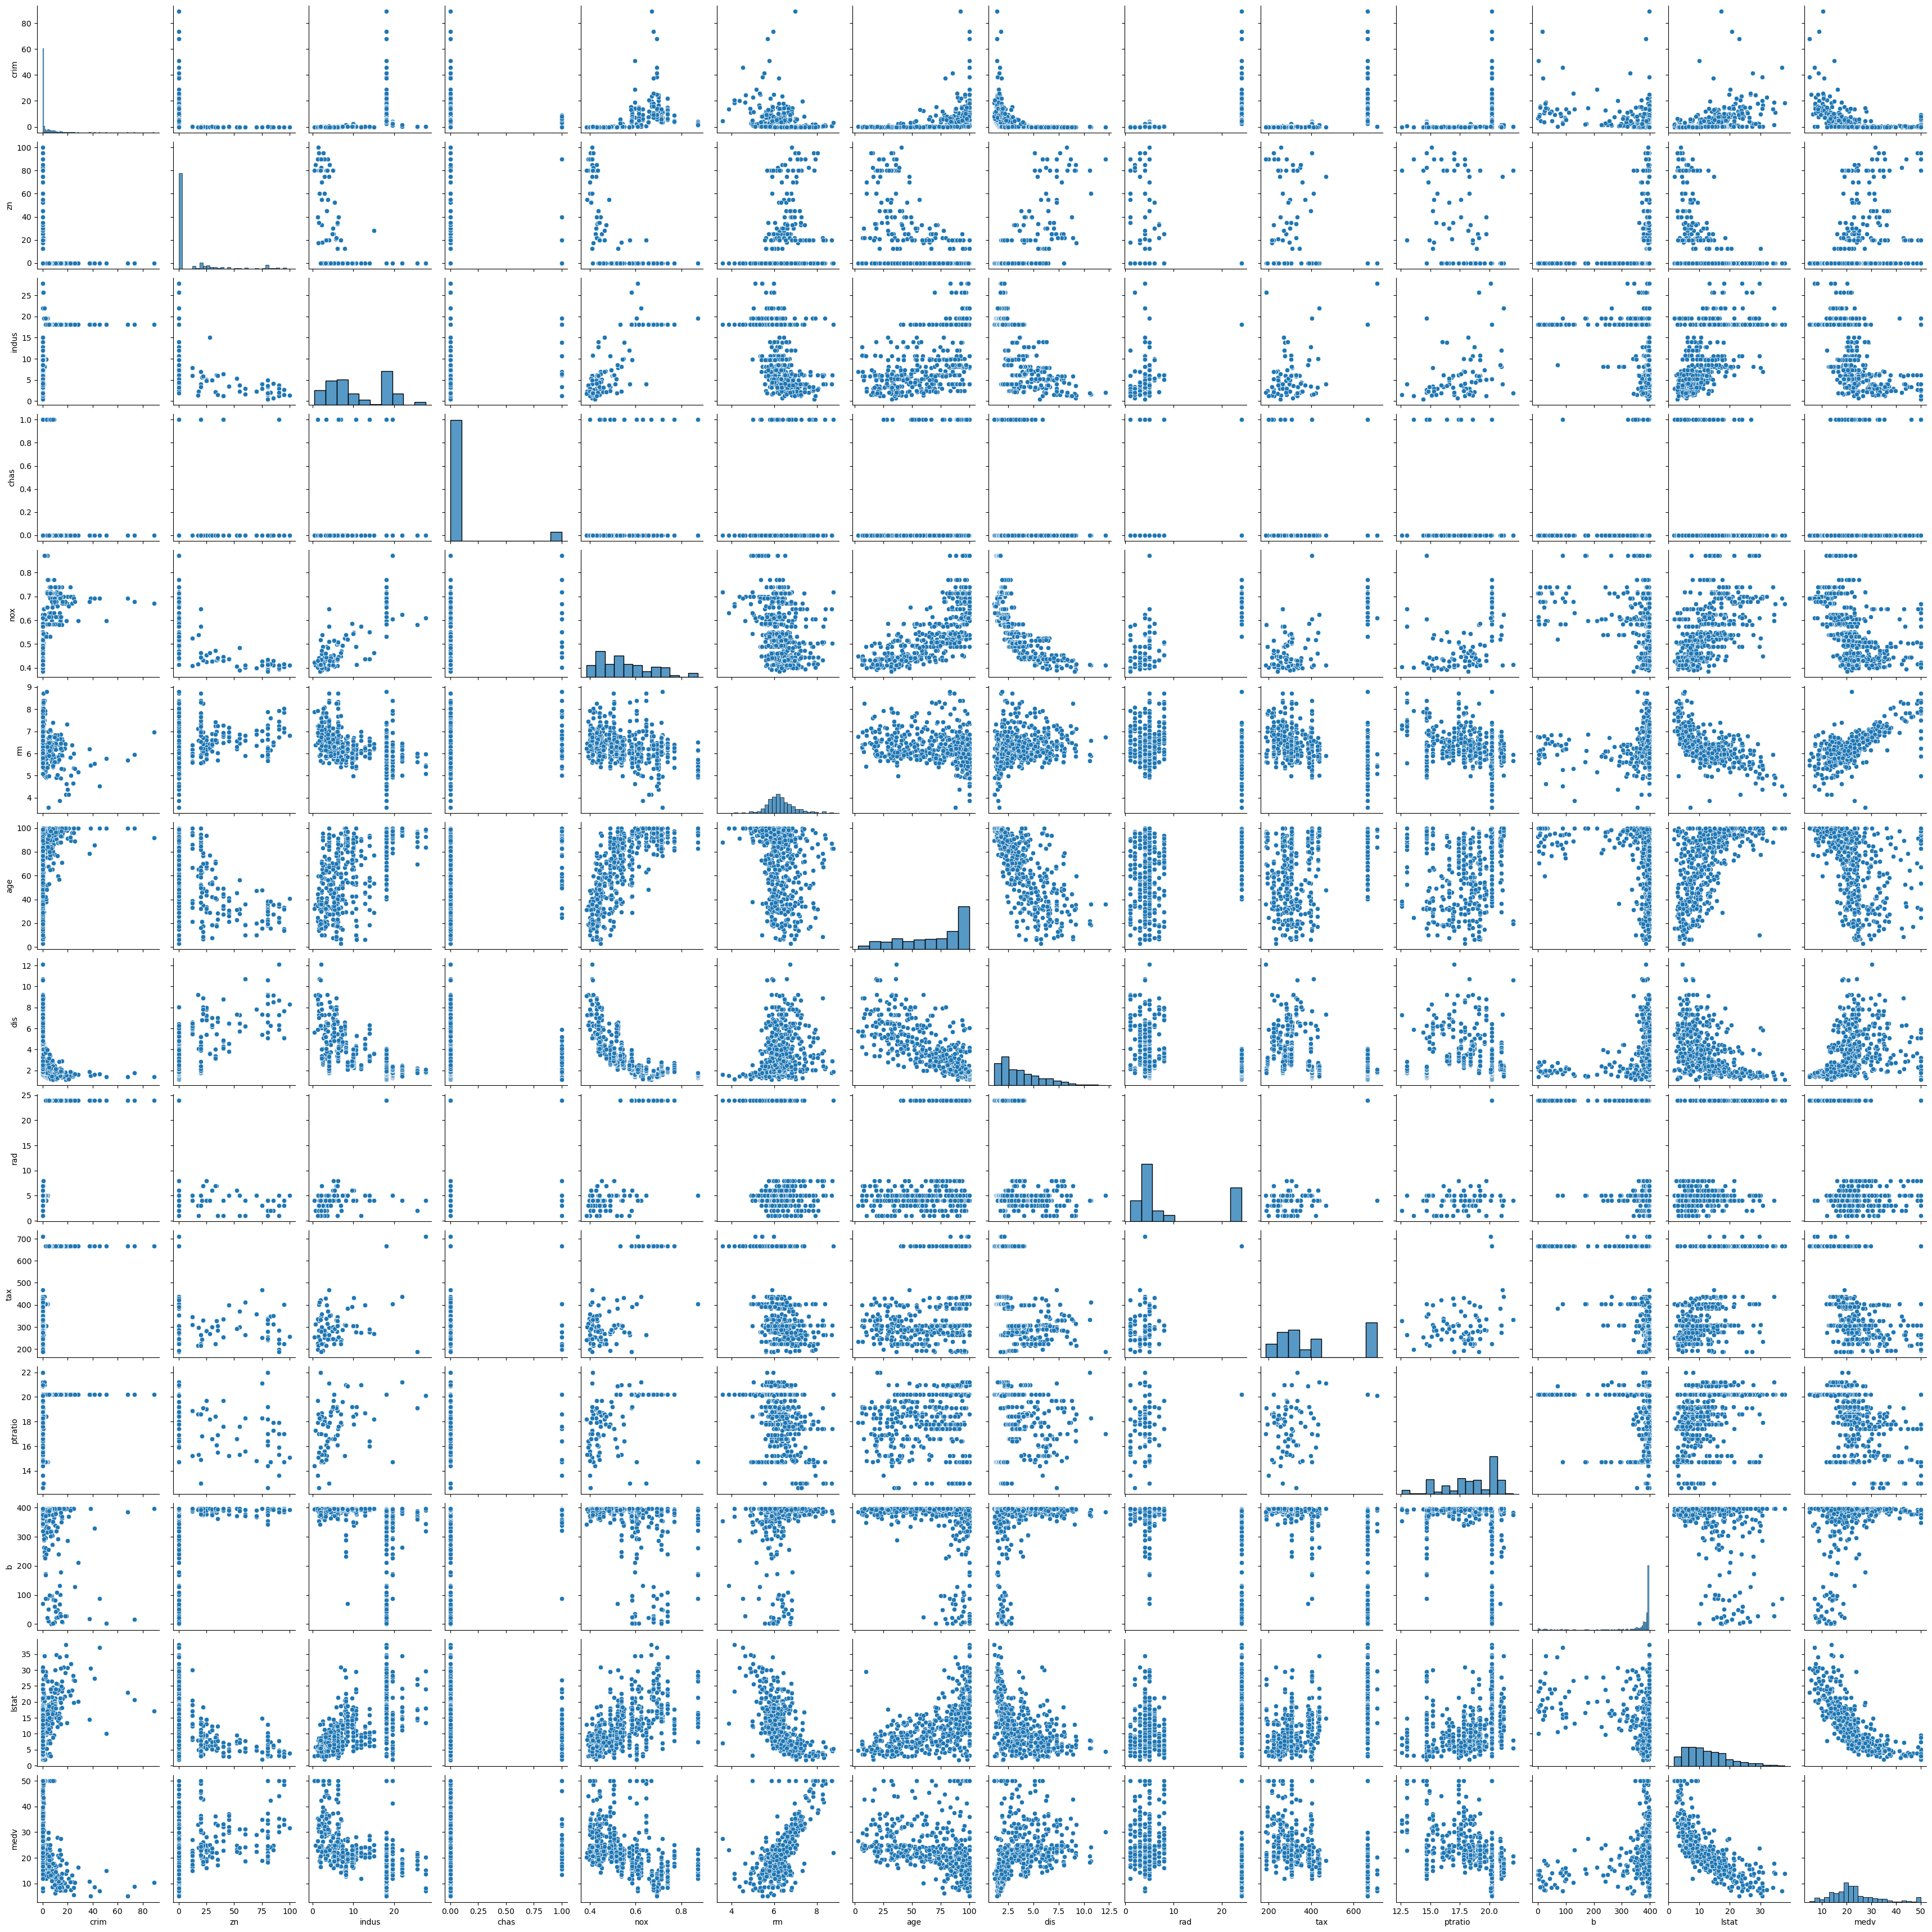

In [176]:
plt.figure(figsize=(20, 20))
plt.suptitle("Pairplot", fontsize=30)
sns.pairplot(df)
plt.show()

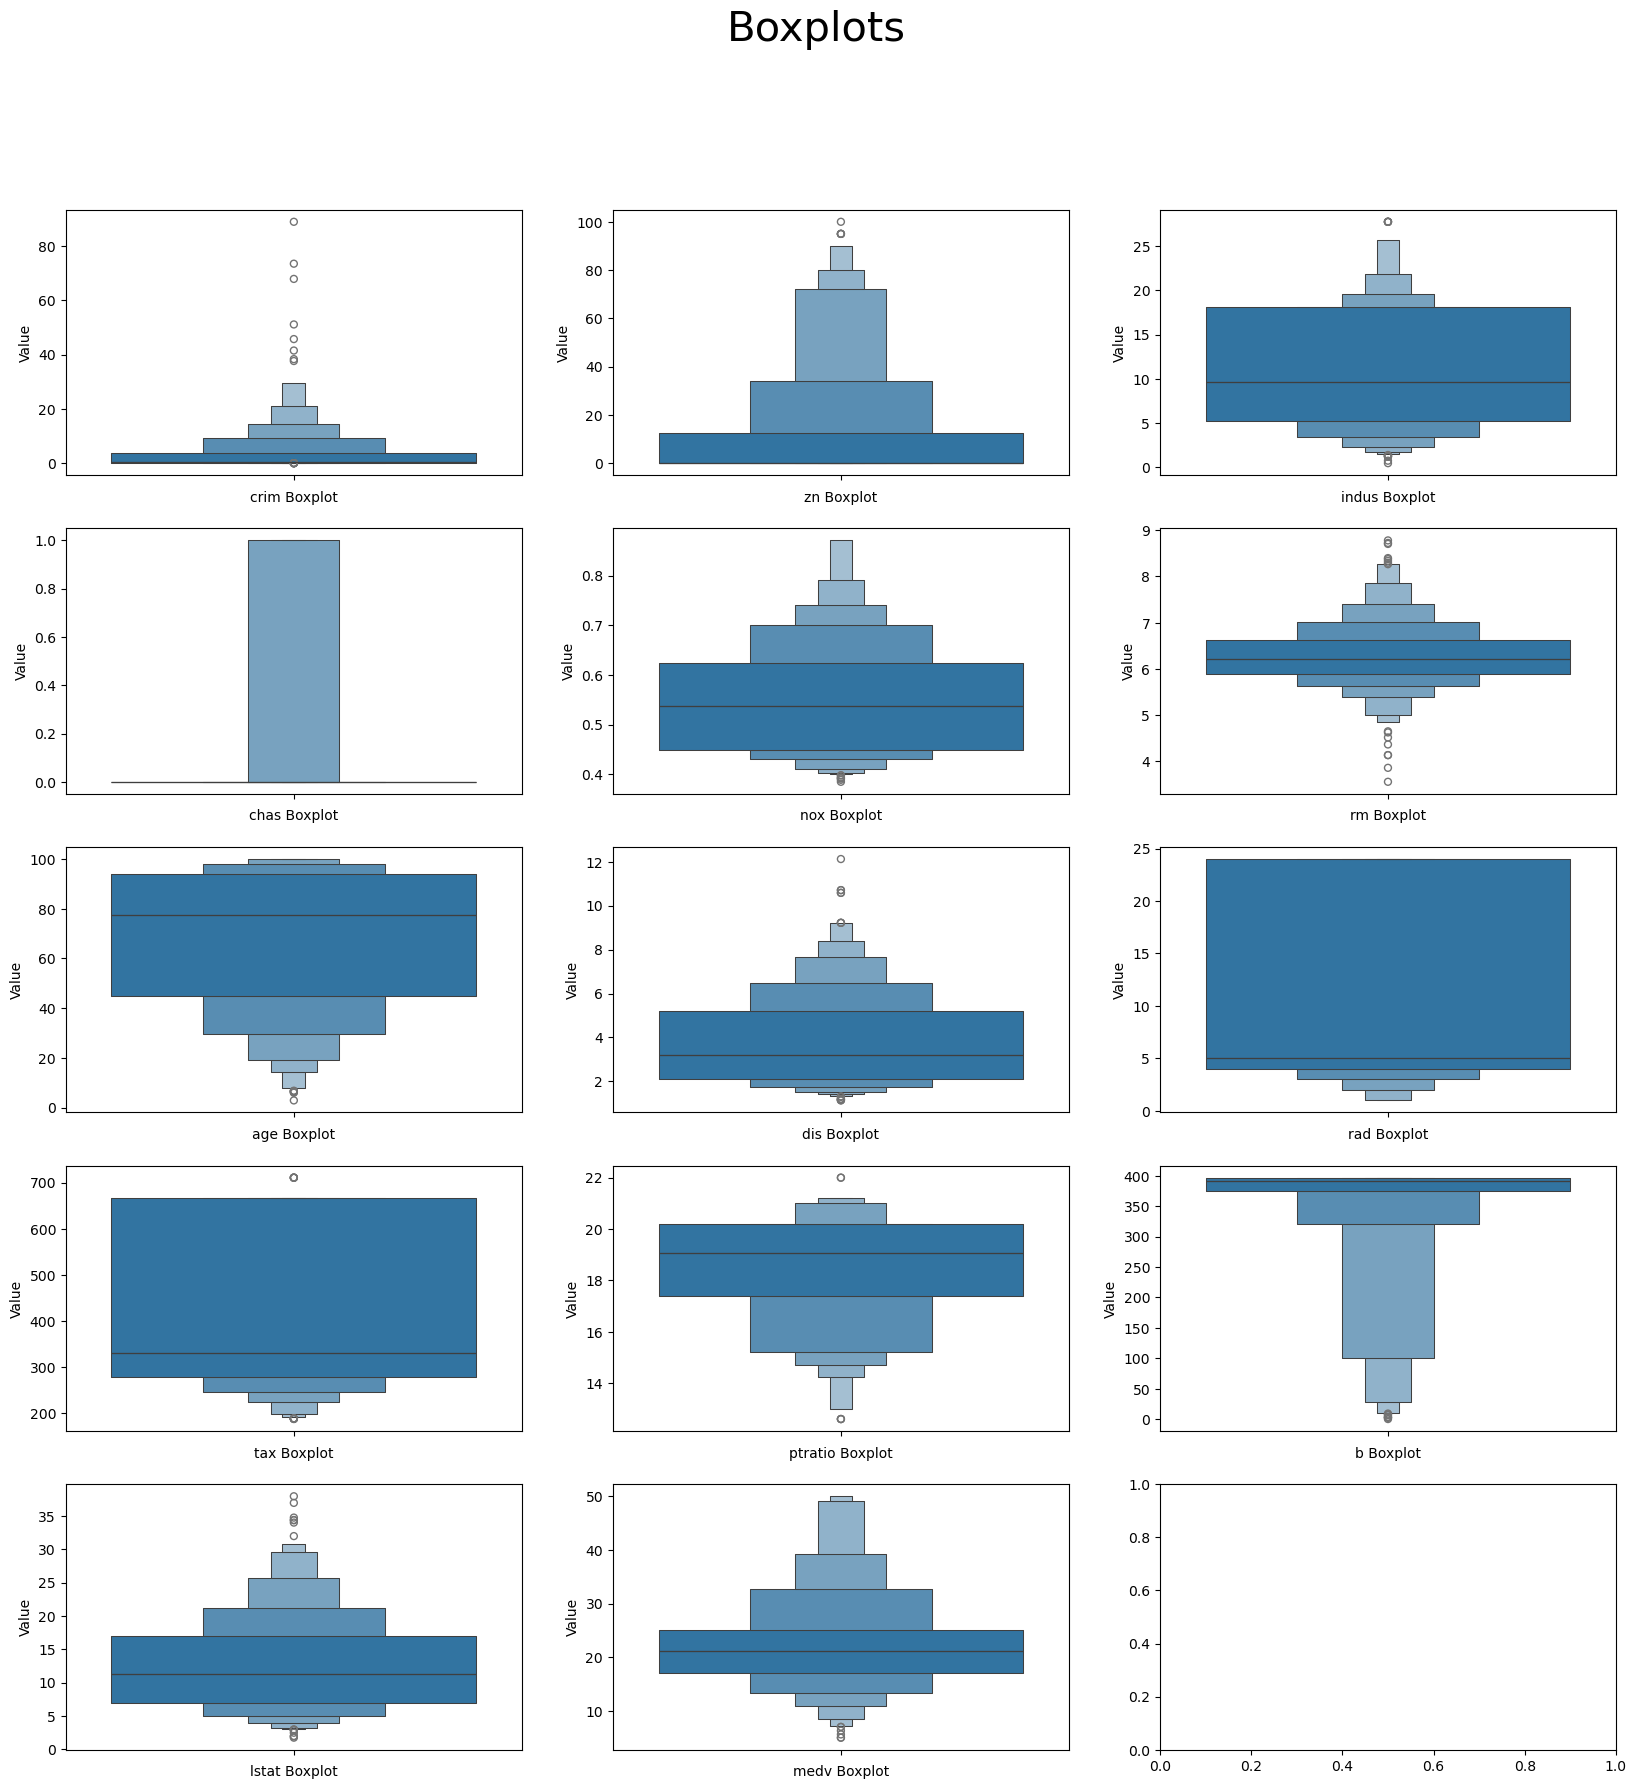

In [177]:
fig, axes = plt.subplots(5, 3, figsize=(20, 20))

fig.suptitle("Boxplots", fontsize=30)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    sns.boxenplot(df[col], ax=ax)
    ax.set_xlabel(f"{col} Boxplot")
    ax.set_ylabel('Value')

plt.show()

In [178]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Feature Selection

In [179]:
np.abs(df.corr()['medv']).sort_values(ascending=False)[1:3].keys()

Index(['lstat', 'rm'], dtype='object')

In [180]:
# select top 2 features
features = ['rm', 'lstat']

X = df[features].values
y = df['medv'].values


# medv vs lstat plot was curved, so log transform
# X[:, 1] = np.log1p(X[:, 1])
X, y

(array([[6.575, 4.98 ],
        [6.421, 9.14 ],
        [7.185, 4.03 ],
        ...,
        [6.976, 5.64 ],
        [6.794, 6.48 ],
        [6.03 , 7.88 ]], shape=(506, 2)),
 array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
        19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
        20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
        23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
        33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
        21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
        20.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

### MLP Model

In [206]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Configuration and Optimizer

In [ ]:
model = MLP()
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
    

### Training with Early Stopping

In [210]:
best_loss = float('inf')
patience = 100
wait = 0
best_state = None

for epoch in range(10000):
    model.train()
    loss = loss_fn(model(X_train_tensor), y_train_tensor)
    opt.zero_grad()
    loss.backward()
    opt.step()
    
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test_tensor), y_test_tensor)
    
    if val_loss.item() < best_loss:
        best_loss = val_loss.item()
        wait = 0
        best_state = model.state_dict()
    else:
        wait += 1
    
    if wait >= patience:
        model.load_state_dict(best_state)
        print(f"Early stopping at epoch {epoch}")
        break

Early stopping at epoch 7529


### Model Evaluation

In [214]:
from sklearn.metrics import r2_score, mean_squared_error

with torch.no_grad():
    y_train_pred = model(X_train_tensor).numpy().ravel()
    y_test_pred = model(X_test_tensor).numpy().ravel()
    
print("Evaluation Results: ")
print(f"Train R2_score:   {r2_score(y_train_tensor, y_train_pred):.3f}")
print(f"Test R2_score:    {r2_score(y_test_tensor, y_test_pred):.3f}")
print(f"\nTrain MSE_score: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f} $")
print(f"Test: MSE_score  {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f} $")
print(f"\n Train and Test R2_score diffrence = {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.3f}")

Evaluation Results: 
Train R2_score:   0.780
Test R2_score:    0.757

Train MSE_score: 4.38 $
Test: MSE_score  4.22 $

 Train and Test R2_score diffrence = 0.023


### Visualization 

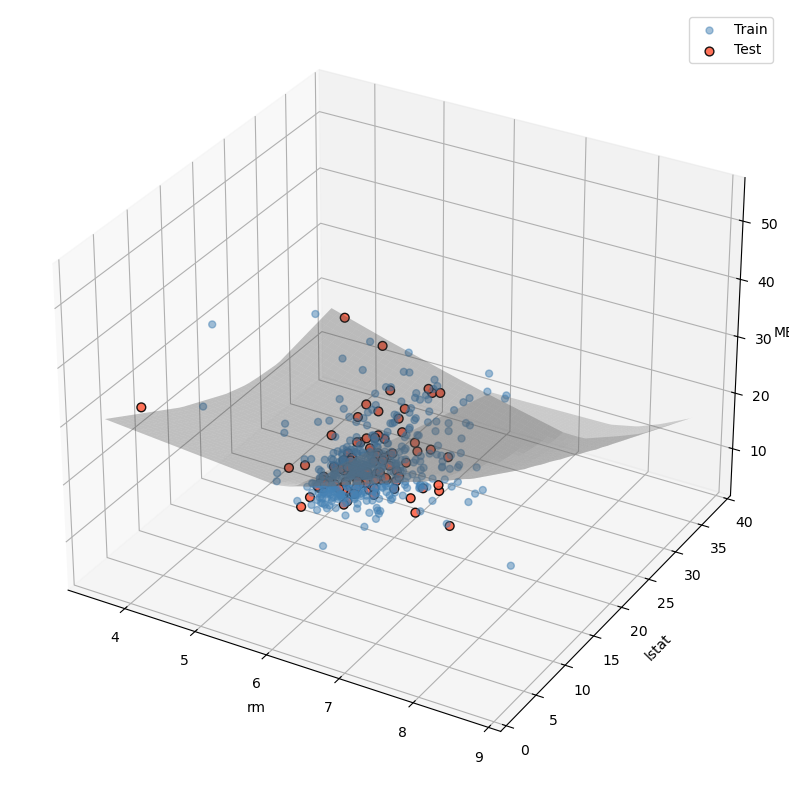

In [216]:
g1, g2 = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 50), np.linspace(X[:, 1].min(), X[:, 1].max(), 50))

grid_raw = np.stack([g1.ravel(), g2.ravel()], axis=1)

model.eval()
with torch.no_grad():
    Z = model(torch.tensor(scaler.transform(grid_raw), dtype=torch.float32)).numpy().ravel()

Z = Z.reshape(g1.shape)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='steelblue', s=25, alpha=0.5, label='Train')
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='tomato', s=40, edgecolors='k', alpha=0.9, label='Test')

ax.plot_surface(g1, g2, Z, color='gray', alpha=0.3)

ax.set_xlabel('rm')
ax.set_ylabel('lstat')
ax.set_zlabel('MEDV')
ax.legend()
plt.tight_layout()
plt.show()

### Report

# گزارش تمرین: پیش‌بینی قیمت خانه با PyTorch

**نام:** علی طبیب آذر

---

## صورت تمرین

پیاده‌سازی یک شبکه پرسپترون روی دیتاست Boston با استفاده از PyTorch، انتخاب دو ویژگی مؤثر بر قیمت، حل مسئله رگرسیون در دو بعد و رسم نمودار سه‌بعدی همراه با سطح پیش‌بینی مدل.

---

## مراحل انجام کار

### ۱. بررسی داده‌ها
دیتاست شامل 506 نمونه و 14 ستون است و مقدار گمشده یا تکراری ندارد.

### ۲. انتخاب ویژگی
با بررسی ماتریس همبستگی، دو ویژگی با بیشترین ارتباط با قیمت انتخاب شدند:
- **rm** (تعداد اتاق) با همبستگی +0.70
- **lstat** (درصد کم‌درآمدها) با همبستگی -0.74

### ۳. آماده‌سازی داده
- تقسیم داده به 80% آموزش و 20% آزمون
- استاندارد سازی ویژگی‌ها (فیت فقط روی داده آموزش)

### ۴. مدل
یک پرسپترون چندلایه با معماری زیر:
ورودی (2) → لایه پنهان (16 نورون + ReLU) → خروجی (1)


- تابع خطا: MSE
- بهینه‌ساز: Adam با نرخ یادگیری 0.001
- توقف زودهنگام (Early Stopping) برای جلوگیری از بیش‌برازش

### ۵. نمودار سه‌بعدی
نقاط داده (آموزش و آزمون) به همراه سطح پیش‌بینی مدل در فضای سه‌بعدی رسم شد. سطح به‌دست‌آمده از مدل، به‌خوبی از میان نقاط عبور می‌کند و شیب آن با انتظارات سازگار است: با افزایش rm قیمت بالا می‌رود و با افزایش lstat کاهش می‌یابد.

---

## نتایج

| متریک | مقدار |
|-------|-------|
| R² آموزش | 0.780 |
| R² آزمون | 0.757 |
| RMSE آزمون | حدود 4.2 هزار دلار |

---

## نتیجه‌گیری

مدل با تنها دو ویژگی توانست حدود 76% از تغییرات قیمت را توضیح دهد. استفاده از لایه پنهان با تابع فعال‌ساز غیرخطی باعث شد مدل رابطه منحنی بین قیمت و lstat را بهتر از یک مدل خطی ساده یاد بگیرد و توقف زودهنگام از حفظ‌کردن داده‌ها توسط مدل جلوگیری کرد.
